In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.filters import threshold_multiotsu
import os

C:\Users\Admin\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


For Lead I

In [2]:
Distorted_img = np.load(r"D:\deep learning data\image dataset\both clear and distorted\00000_wrinkled_segmented_leadwise\00000_I.npy")

In [3]:
Distorted_img.shape

(987, 354, 492, 3)

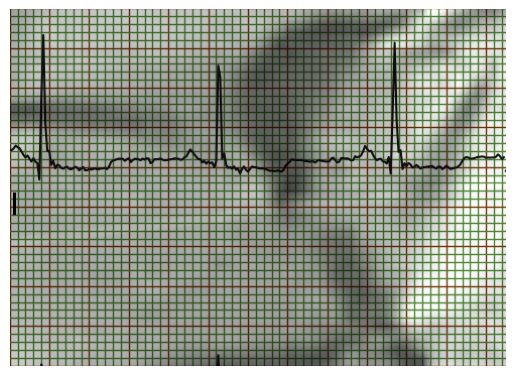

In [4]:
plt.imshow(Distorted_img[600], cmap='gray')
plt.axis('off')
plt.show()

In [5]:
processed_images = []

# Define the kernel for morphology operations
kernel = np.ones((2, 2), np.uint8)

# Process each image
for image in Distorted_img:
    # Step 1: Convert RGB to HSV and extract the value channel
    hsv_image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    value_channel = hsv_image[:, :, 2]

    # Step 2: Apply multi-Otsu thresholding
    thresholds = threshold_multiotsu(value_channel, classes=3)
    regions = np.digitize(value_channel, bins=thresholds)

    # Step 3: Identify dark regions
    dark_regions = np.where(regions == 0, 255, 0).astype(np.uint8)

    # Step 4: Apply morphological opening and closing
    opened_image = cv2.morphologyEx(dark_regions, cv2.MORPH_OPEN, kernel)
    thick_regions = cv2.morphologyEx(opened_image, cv2.MORPH_CLOSE, kernel)

    # Step 5: Invert the final image
    inverted_image = cv2.bitwise_not(thick_regions)

    # Append processed image to the list
    processed_images.append(inverted_image)

# Convert the list of processed images to a numpy array
processed_images = np.array(processed_images)

# Save the processed images if needed
#np.save("processed_images_I.npy", processed_images)

In [7]:
np.save(r"D:\deep learning data\image dataset\both clear and distorted\00000_wrinkled_segmented_leadwise_processed\processed_I.npy", processed_images)

In [8]:
processed_img = np.load(r"D:\deep learning data\image dataset\both clear and distorted\00000_wrinkled_segmented_leadwise_processed\processed_I.npy")

In [9]:
processed_img.shape

(987, 354, 492)

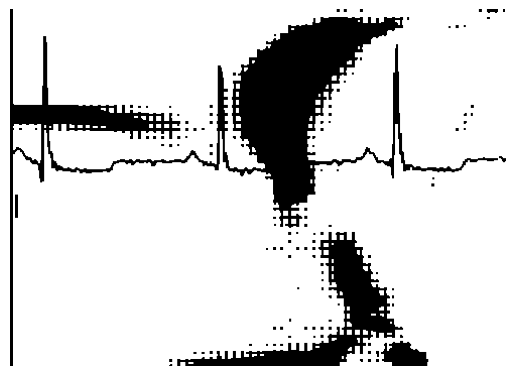

In [10]:
plt.imshow(processed_img[600], cmap='gray')
plt.axis('off')
plt.show()

In [11]:
GT_img_processed = np.load(r"D:\deep learning data\image dataset\without_grid_segmented\00000_all_leads_leadnames_leadwise\00000_I.npy")

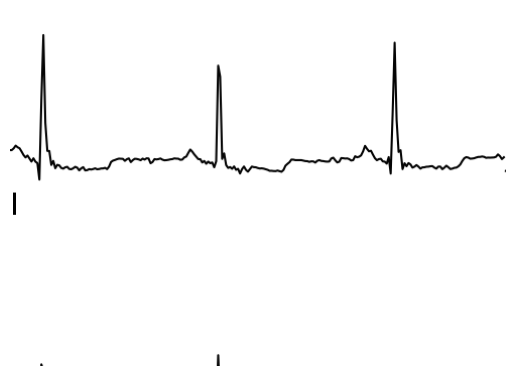

In [12]:
plt.imshow(GT_img_processed[600], cmap='gray')
plt.axis('off')
plt.show()

In [13]:
GT_img_processed.shape

(987, 354, 492, 3)

In [14]:
# Initialize an empty list to hold the processed images
processed_images = []

# Process each image in input_img
for image in GT_img_processed:
    # Step 1: Convert RGB to HSV and extract the value channel
    hsv_image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    value_channel = hsv_image[:, :, 2]
    
    # Step 2: Binarize the value channel
    _, binarized = cv2.threshold(value_channel, 127, 255, cv2.THRESH_BINARY)
    
    # Append the processed (binarized) image to the list
    processed_images.append(binarized)

# Convert the list of processed images to a numpy array
GT_processed_images = np.array(processed_images)

# Save the processed images (optional)

In [15]:
GT_processed_images.shape

(987, 354, 492)

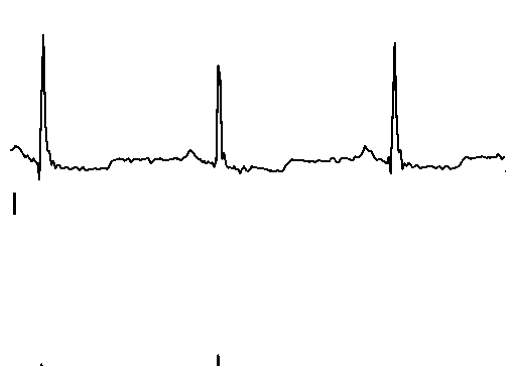

In [16]:
plt.imshow(GT_processed_images[600], cmap='gray')
plt.axis('off')
plt.show()

In [17]:
np.save(r"D:\deep learning data\image dataset\without_grid_segmented\00000_all_leads_leadnames_leadwise_processed\GT_img_I.npy", processed_images)

In [18]:
GT_processed_images = np.load(r"D:\deep learning data\image dataset\without_grid_segmented\00000_all_leads_leadnames_leadwise_processed\GT_img_I.npy")

In [ ]:
from skimage.metrics import structural_similarity as ssim

In [19]:
def dice_coefficient(gt_img, proc_img):
    intersection = np.sum((gt_img > 0) & (proc_img > 0))
    return (2.0 * intersection) / (np.sum(gt_img > 0) + np.sum(proc_img > 0))

# Calculate Dice coefficient for each image pair and store results
dice_scores = []
for gt_img, proc_img in zip( GT_processed_images,processed_img):
    score = dice_coefficient(gt_img, proc_img)
    dice_scores.append(score)

# Calculate the average Dice coefficient across all image pairs
average_dice = np.mean(dice_scores)

print("Average Dice Coefficient:", average_dice)

Average Dice Coefficient: 0.9698982322824211


In [23]:
from skimage.metrics import structural_similarity as ssim
# Initialize list to hold SSIM scores
ssim_scores = []

# Iterate through the processed and ground truth image arrays
for p_img, g_img in zip(processed_img, GT_processed_images):
    # Calculate SSIM
    ssim_value = ssim(p_img, g_img, data_range=255)  # Adjust data_range based on image scale
    ssim_scores.append(ssim_value)

# Convert SSIM scores to an array for summary
ssim_scores = np.array(ssim_scores)

# Print average SSIM score
print(f"Average SSIM: {ssim_scores.mean():.4f}")


Average SSIM: 0.8860
